In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/39.2 MB 31.6 MB/s eta 0:00:02
   --------- ------------------------------ 9.7/39.2 MB 23.9 MB/s eta 0:00:02
   ------------------ --------------------- 18.4/39.2 MB 30.0 MB/s eta 0:00:01
   --------------------------- ------------ 26.7/39.2 MB 32.6 MB/s eta 0:00:01
   ----------------------------------- ---- 35.1/39.2 MB 34.3 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.2 MB 35.0 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 30.9 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 22.6 MB/s  0:00:00

   ---------------------------------------- 0/8 [tqdm]
   -------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

load Data

In [3]:
df = pd.read_csv(r"C:\Users\sg961\OneDrive\Desktop\customer-churn-prediction\Data\telco_churn.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Checking Data types & Missing Values

In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["Churn"].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Fix the sneaky TotalCharges column

In [5]:
# Convert TotalCharges to numeric (blanks become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many became NaN
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# Fill missing with 0 (these are brand new customers with 0 tenure)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Missing TotalCharges: 11


encode the target

In [6]:
# customerID is just a unique ID, useless for prediction
df = df.drop("customerID", axis=1)

# Encode target: Yes=1, No=0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Target distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.1%}")

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


Quick Visualization

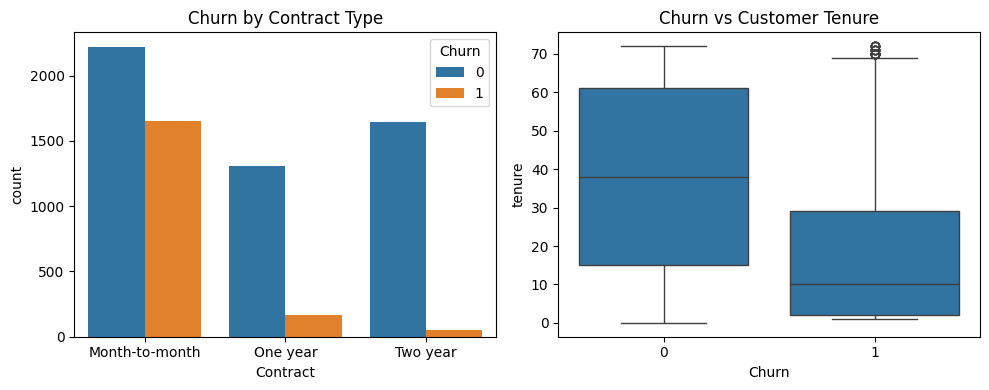

In [7]:
# Plot churn rate by contract type
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Churn vs Customer Tenure")

plt.tight_layout()
plt.show()

In [8]:
# Check which columns are still text
print("Categorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Encode categorical features

In [9]:
# One-hot encode all categorical columns at once
df_encoded = pd.get_dummies(df, drop_first=True)

# Convert any True/False columns to 1/0
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes("bool").columns})

print("New shape:", df_encoded.shape)
print("\nFirst 5 rows:")
df_encoded.head()

New shape: (7043, 31)

First 5 rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


Train/test split

In [10]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")

Train shape: (5634, 30)
Test shape: (1409, 30)
Train churn rate: 26.5%
Test churn rate: 26.5%


Scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Ready to train models.")

Scaling done. Ready to train models.


 Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print("="*40)
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.3f}")

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.842


XGBoost classifier

In [13]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print("="*40)
print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.3f}")

XGBoost Results
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.837


Apply SMOTE to fix class imbalance

In [14]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original train churn rate: {y_train.mean():.1%}")
print(f"After SMOTE churn rate:    {y_train_smote.mean():.1%}")
print(f"New train size: {X_train_smote.shape[0]} (was {X_train.shape[0]})")

Original train churn rate: 26.5%
After SMOTE churn rate:    50.0%
New train size: 8278 (was 5634)


Retrain XGBoost with SMOTE

In [15]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)
xgb_smote.fit(X_train_smote, y_train_smote)

xgb_smote_pred = xgb_smote.predict(X_test)
xgb_smote_proba = xgb_smote.predict_proba(X_test)[:, 1]

print("XGBoost + SMOTE Results")
print("="*40)
print(classification_report(y_test, xgb_smote_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_smote_proba):.3f}")

XGBoost + SMOTE Results
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC: 0.831


Confusion matrix

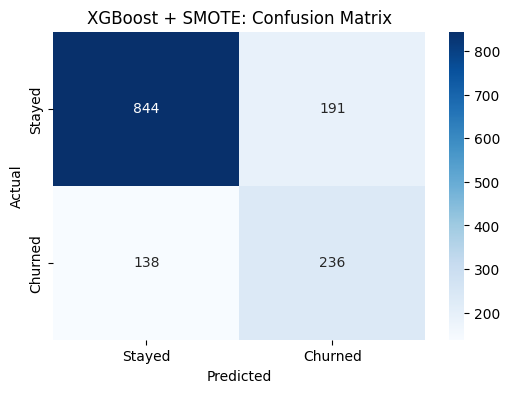


True churners caught: 236 out of 374 (63.1%)
False alarms: 191 (customers we'd offer discounts to unnecessarily)
Missed churners: 138 (customers we'd lose)


In [16]:
cm = confusion_matrix(y_test, xgb_smote_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churned"],
            yticklabels=["Stayed", "Churned"])
plt.title("XGBoost + SMOTE: Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Calculate business impact
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue churners caught: {tp} out of {tp+fn} ({tp/(tp+fn):.1%})")
print(f"False alarms: {fp} (customers we'd offer discounts to unnecessarily)")
print(f"Missed churners: {fn} (customers we'd lose)")

Feature importance

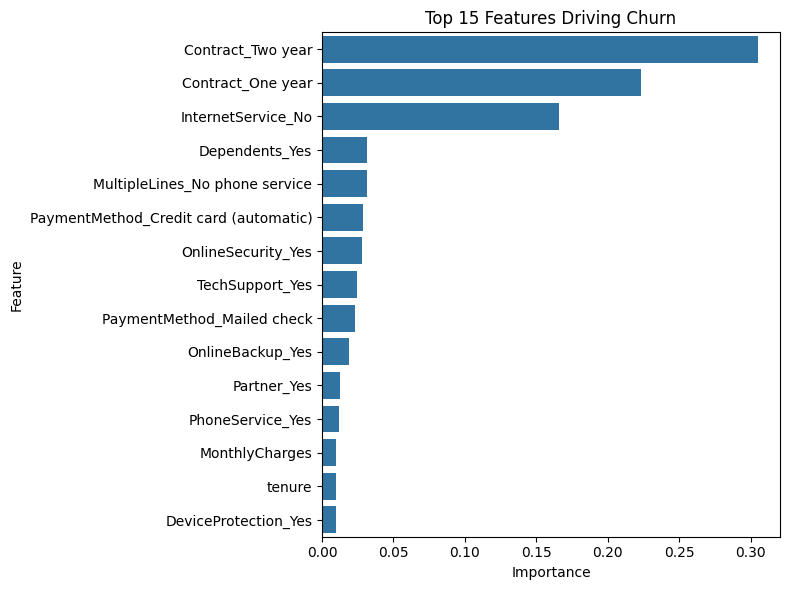

                                  Feature  Importance
25                      Contract_Two year    0.305347
24                      Contract_One year    0.223031
11                     InternetService_No    0.165586
6                          Dependents_Yes    0.031785
8          MultipleLines_No phone service    0.031670
27  PaymentMethod_Credit card (automatic)    0.028644
13                     OnlineSecurity_Yes    0.027680
19                        TechSupport_Yes    0.024149
29             PaymentMethod_Mailed check    0.022844
15                       OnlineBackup_Yes    0.018599
5                             Partner_Yes    0.012654
7                        PhoneService_Yes    0.011940
2                          MonthlyCharges    0.009860
1                                  tenure    0.009832
17                   DeviceProtection_Yes    0.009826


In [17]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_smote.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance, y="Feature", x="Importance")
plt.title("Top 15 Features Driving Churn")
plt.tight_layout()
plt.show()

print(importance)

ROC curve

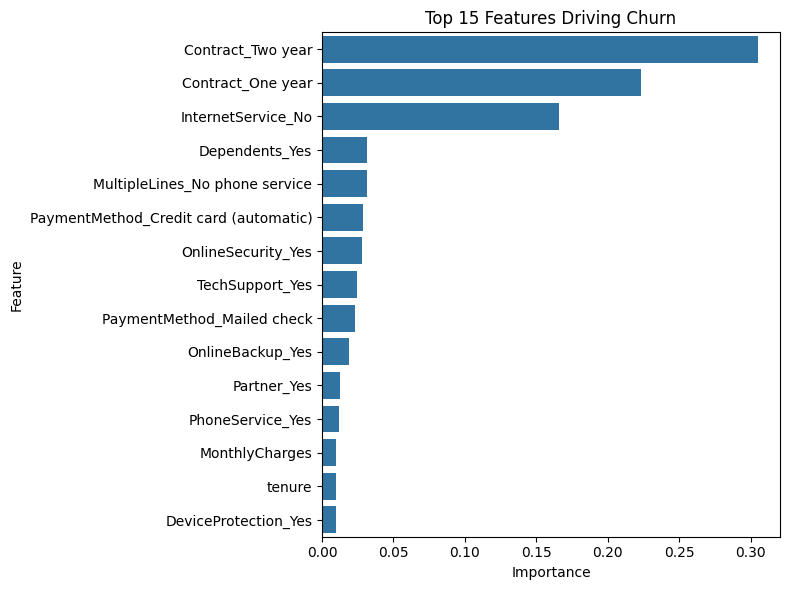

In [24]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importance, y="Feature", x="Importance")
plt.title("Top 15 Features Driving Churn")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

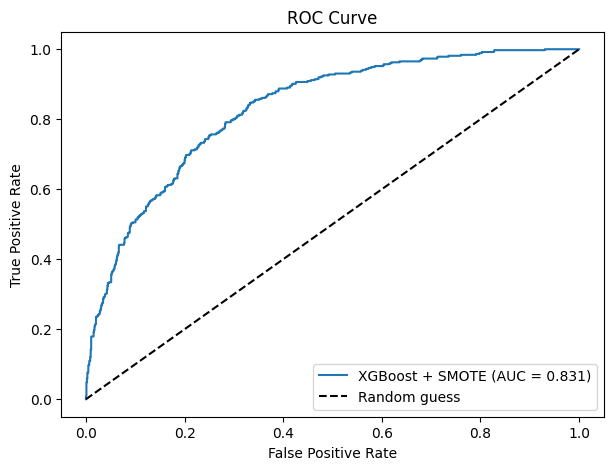

In [18]:
fpr, tpr, _ = roc_curve(y_test, xgb_smote_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost + SMOTE (AUC = {roc_auc_score(y_test, xgb_smote_proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [21]:
import os
os.makedirs("outputs", exist_ok=True)
print("✅ outputs folder ready")

✅ outputs folder ready


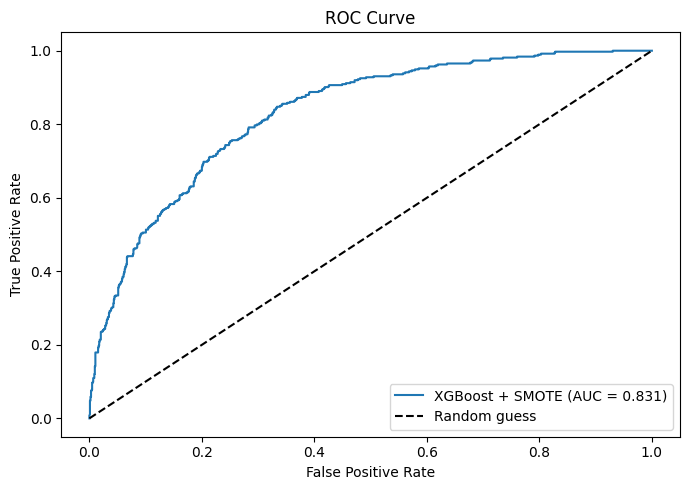

✅ ROC curve saved to outputs/roc_curve.png


In [23]:
# Save the ROC curve image
fpr, tpr, _ = roc_curve(y_test, xgb_smote_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost + SMOTE (AUC = {roc_auc_score(y_test, xgb_smote_proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ ROC curve saved to outputs/roc_curve.png")

In [22]:
# 1. Save predictions
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_smote_pred,
    "Churn_Probability": xgb_smote_proba.round(3)
})
results.to_csv("outputs/churn_predictions.csv", index=False)

# 2. Save metrics comparison
metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "XGBoost + SMOTE"],
    "ROC_AUC": [0.842, 0.837, 0.831],
    "Recall_Churn": [0.57, 0.52, 0.63],
    "Precision_Churn": [0.66, 0.63, 0.55]
})
metrics.to_csv("outputs/model_metrics.csv", index=False)

# 3. Save feature importance
importance.to_csv("outputs/feature_importance.csv", index=False)

print("✅ All outputs saved to outputs/ folder")

✅ All outputs saved to outputs/ folder
